In [1]:
import scanpy as sc
import numpy as np
import scvelo as scv
import matplotlib.pyplot as plt
import pandas as pd
import scipy

In [2]:
adata = sc.read('adata_umap_pca.h5')

In [3]:
#adata_t = sc.read(dir_data + 'adata_umap_pca.h5')

In [4]:
lista_colori = [
"#f9decf",
"#c9a997",
"#C72228",
"#EF4E22",  
"#f77b59",
"#FBBE92"]

adata.uns['celltype_colors'] = lista_colori


In [5]:
adata = adata[(adata.obs['celltype'] == 'Haematoendothelial progenitors') |
                  (adata.obs['celltype'] == 'Erythroid1') | 
                  (adata.obs['celltype'] == 'Erythroid2') |
                  (adata.obs['celltype'] == 'Erythroid3') | 
                  (adata.obs['celltype'] == 'Blood progenitors 1') |
                  (adata.obs['celltype'] == 'Blood progenitors 2'),:].copy()

In [6]:
vecH = np.array(adata.obs.celltype == 'Haematoendothelial progenitors')
vecB1 = np.array(adata.obs.celltype == 'Blood progenitors 1')
vecB2 = np.array(adata.obs.celltype == 'Blood progenitors 2')
vecE1 = np.array(adata.obs.celltype == 'Erythroid1')
vecE2 = np.array(adata.obs.celltype == 'Erythroid2')
vecE3 = np.array(adata.obs.celltype == 'Erythroid3')

In [7]:
scv.pp.filter_and_normalize(adata,min_shared_counts=20,n_top_genes=5000)

Filtered out 46658 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Exctracted 5000 highly variable genes.
Logarithmized X.


In [8]:
scv.pp.moments(adata,n_pcs=50,n_neighbors=30)

computing neighbors
    finished (0:00:16) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:05) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [9]:
lista_vec = [vecH,vecB1,vecB2,vecE1,vecE2,vecE3]

In [10]:
lista_pop = ['Haematoendothelial progenitors','Blood progenitors 1',
        'Blood progenitors 2', 'Erythroid1','Erythroid2', 'Erythroid3']

# imputed

In [11]:
mat_s = pd.DataFrame(adata.layers['Ms'].copy())
mat_u = pd.DataFrame(adata.layers['Mu'].copy())
mat_s.index = adata.obs_names
mat_s.columns = adata.var_names
mat_u.index = adata.obs_names
mat_u.columns = adata.var_names

In [12]:
df_sl = pd.DataFrame(index=adata.var_names)
df_db = pd.DataFrame(index=adata.var_names)
df_int = pd.DataFrame(index=adata.var_names)
df_dq = pd.DataFrame(index=adata.var_names)

In [13]:
for pop in lista_pop:
    print(pop)
    vec = adata.obs['celltype'] == pop
    
    x = mat_s.loc[vec]
    y = mat_u.loc[vec]
    
    mx = np.mean(x)
    my = np.mean(y)
    x_mx = x - mx
    y_my = y - my
    xy = np.sum(x_mx * y_my, axis = 0)
    X2 = np.sum(x_mx**2,axis = 0)
    sl = xy / X2
    inter = my - sl * mx
    n = np.sum(vec)
                
    df_sl[pop] = pd.DataFrame(sl)
    df_int[pop] = pd.DataFrame(inter)
     
    
    pred = sl * x + inter
    sse = (pred - y)**2
    SSE = np.sum(sse, axis = 0)
                
    db = np.sqrt(SSE/(n-2)/X2)
    df_db[pop] = pd.DataFrame(db)
    
    dq = np.sqrt(SSE * (1/n + mx**2/X2)/ (n-2))
    df_dq[pop] = pd.DataFrame(dq)

Haematoendothelial progenitors
Blood progenitors 1
Blood progenitors 2
Erythroid1
Erythroid2
Erythroid3


In [14]:
df_exp = pd.DataFrame(index=adata.var_names)
df_de = pd.DataFrame(index=adata.var_names)

In [15]:
mat_s2 = pd.DataFrame(adata.layers['Ms'].copy())
mat_s2.columns = adata.var_names
mat_s2.index = adata.obs_names

In [16]:
for pop in lista_pop:
    print(pop)
    vec = adata.obs['celltype'] == pop
    n = np.sum(vec)
    expr = np.mean(mat_s2.loc[vec],axis =0)
    dex = np.std(mat_s2.loc[vec],axis =0)/np.sqrt(n)
    
    df_exp[pop] = pd.DataFrame(expr)
    df_de[pop] = pd.DataFrame(dex)

Haematoendothelial progenitors
Blood progenitors 1
Blood progenitors 2
Erythroid1
Erythroid2
Erythroid3


In [17]:
df_quan = pd.DataFrame(index=adata.var_names)

for pop in lista_pop:
    vec = adata.obs['celltype'] == pop
    n = np.sum(vec)
    
    df_quan[pop] = scipy.stats.t.ppf(0.95, n - 1)

df_conf = df_db * df_quan

df_min = df_sl - df_conf
df_max = df_sl + df_conf

In [18]:
gene = 'Abcb10'

In [19]:
df_sl.loc[gene]

Haematoendothelial progenitors    0.066753
Blood progenitors 1               0.109420
Blood progenitors 2               0.105140
Erythroid1                        0.048010
Erythroid2                        0.014344
Erythroid3                        0.031954
Name: Abcb10, dtype: float32

In [20]:
df_min.loc[gene]

Haematoendothelial progenitors    0.062007
Blood progenitors 1               0.097021
Blood progenitors 2               0.096596
Erythroid1                        0.039866
Erythroid2                       -0.003360
Erythroid3                        0.017569
Name: Abcb10, dtype: float64

In [21]:
df_max.loc[gene]

Haematoendothelial progenitors    0.071499
Blood progenitors 1               0.121818
Blood progenitors 2               0.113685
Erythroid1                        0.056154
Erythroid2                        0.032048
Erythroid3                        0.046340
Name: Abcb10, dtype: float64

In [22]:
df_exp.loc[gene]

Haematoendothelial progenitors    0.214581
Blood progenitors 1               0.497311
Blood progenitors 2               0.828300
Erythroid1                        1.257230
Erythroid2                        1.479675
Erythroid3                        1.514681
Name: Abcb10, dtype: float32

In [23]:
rel_dif = pd.DataFrame((df_sl['Erythroid3'] - df_sl['Erythroid2'])/df_sl['Erythroid3']) 

In [24]:
vec_mean = ((df_exp['Erythroid3'] >  df_exp['Erythroid2'])
            &(df_exp['Erythroid3'] >  df_exp['Erythroid1'])
            &(df_exp['Erythroid3'] >  df_exp['Blood progenitors 1'])
            &(df_exp['Erythroid3'] >  df_exp['Blood progenitors 2'])
            &(df_exp['Erythroid3'] >  df_exp['Haematoendothelial progenitors']))

In [25]:
vec_sl = (df_sl['Erythroid3'] > df_sl['Erythroid2']) 

In [26]:
vec_pos =  df_sl['Erythroid3']>0

In [27]:
vec_test = df_min['Erythroid3'] > df_max['Erythroid2']

In [28]:
vec_tot = np.array(vec_sl) & np.array(vec_mean) & np.array(vec_pos) & np.array(vec_test)

In [33]:
vec_test

index
Sox17      False
Vcpip1      True
Snhg6       True
Arfgef1    False
Tram1      False
           ...  
Arhgap6    False
Uty        False
Ddx3y      False
Eif2s3y     True
Gm47283     True
Length: 5000, dtype: bool

In [29]:
rds = rel_dif.loc[vec_tot].sort_values(by = 0,ascending=False)

In [30]:
adata.var_names[vec_tot]

Index(['Mgst3', 'Ppox', 'Ercc5', 'Creg1', 'Nudt4', 'Arid3a', 'Ddc', 'Dhrs11',
       'Slc4a1', 'Dcxr', 'Cpeb4', 'Hba-x', 'Hba-a1', 'Hba-a2', 'Gps2',
       'Samd14', 'Ifi35', 'Acp1', 'Cltb', 'Slc25a37', 'Cdkn3', 'Nfe2', 'Ncf4',
       'Grap2', 'Tnrc6b', 'Cdkn1a', 'Rhag', 'Celf4', 'Fech', 'Redrum',
       'Gpcpd1', 'Tgm2', 'Slc43a3', 'Adal', 'Cdc25b', 'Fam210b', 'Pex2',
       'Hsd3b6', 'Pklr', 'Selenbp1', 'Slc39a8', 'Hemgn', 'Mllt3', 'Smim1',
       'Fam126a', 'Klf3', 'Mkrn1', 'Hebp1', 'Bpgm', 'Abcg2', 'Lockd', 'Cox6b2',
       'Ftl1', 'Hbb-bt', 'Hbb-bh1', 'Hbb-y', 'Ano1', 'Kmt5c', 'Blvrb', 'Arrb1',
       'Ucp2', 'Aqp8', 'Gypa', 'Cog2', 'Acp5', 'Hmbs', 'Nxpe2', 'Etfa', 'Apeh',
       'Dapk2', 'Gpx1', 'Txlng', 'Alas2'],
      dtype='object', name='index')

In [36]:
np.sum(vec_tot)

73

# no imputed

In [37]:
mat_s = pd.DataFrame(adata.layers['spliced'].todense().copy())
mat_u = pd.DataFrame(adata.layers['unspliced'].todense().copy())
mat_s.index = adata.obs_names
mat_s.columns = adata.var_names
mat_u.index = adata.obs_names
mat_u.columns = adata.var_names

In [38]:
df_sl_ni = pd.DataFrame(index=adata.var_names)
df_db_ni = pd.DataFrame(index=adata.var_names)

In [39]:
for pop in lista_pop:
    print(pop)
    vec = adata.obs['celltype'] == pop
    
    x = mat_s.loc[vec]
    y = mat_u.loc[vec]
    
    mx = np.mean(x)
    my = np.mean(y)
    x_mx = x - mx
    y_my = y - my
    xy = np.sum(x_mx * y_my, axis = 0)
    X2 = np.sum(x_mx**2,axis = 0)
    sl = xy / X2
    inter = my - sl * mx
    n = np.sum(vec)
                
    df_sl_ni[pop] = pd.DataFrame(sl)
     
    
    pred = sl * x + inter
    sse = (pred - y)**2
    SSE = np.sum(sse, axis = 0)
                
    db = np.sqrt(SSE/(n-2)/X2)
    df_db_ni[pop] = pd.DataFrame(db)
    

Haematoendothelial progenitors
Blood progenitors 1
Blood progenitors 2
Erythroid1
Erythroid2
Erythroid3


In [40]:
df_exp_ni = pd.DataFrame(index=adata.var_names)

mat_s2 = pd.DataFrame(adata.layers['spliced'].todense().copy())
mat_s2.columns = adata.var_names
mat_s2.index = adata.obs_names

for pop in lista_pop:
    print(pop)
    vec = adata.obs['celltype'] == pop
    n = np.sum(vec)
    expr = np.mean(mat_s2.loc[vec],axis =0)
    dex = np.std(mat_s2.loc[vec],axis =0)/np.sqrt(n)
    
    df_exp_ni[pop] = pd.DataFrame(expr)

Haematoendothelial progenitors
Blood progenitors 1
Blood progenitors 2
Erythroid1
Erythroid2
Erythroid3


In [41]:
df_quan_ni = pd.DataFrame(index=adata.var_names)

for pop in lista_pop:
    vec = adata.obs['celltype'] == pop
    n = np.sum(vec)
    
    df_quan_ni[pop] = scipy.stats.t.ppf(0.95, n - 1)

df_conf_ni = df_db_ni * df_quan_ni

df_min_ni = df_sl_ni - df_conf_ni
df_max_ni = df_sl_ni + df_conf_ni

In [42]:
rel_dif = pd.DataFrame((df_sl_ni['Erythroid3'] - df_sl_ni['Erythroid2'])/df_sl_ni['Erythroid3']) 

In [43]:
vec_sl_ni = df_sl_ni['Erythroid3'] > df_sl_ni['Erythroid2']
vec_test_ni = df_min_ni['Erythroid3'] > df_max_ni['Erythroid2']
vec_pos_ni =  df_sl_ni['Erythroid3']>0
vec_mean_ni = ((df_exp_ni['Erythroid3'] >  df_exp_ni['Erythroid2']) 
               &(df_exp_ni['Erythroid3'] >  df_exp_ni['Erythroid1'])
              &(df_exp_ni['Erythroid3'] >  df_exp_ni['Blood progenitors 1'])
              &(df_exp_ni['Erythroid3'] >  df_exp_ni['Blood progenitors 2'])
                 &(df_exp_ni['Erythroid3'] >  df_exp_ni['Haematoendothelial progenitors']))


In [44]:
vec_tot_ni = np.array(vec_sl_ni) & np.array(vec_mean_ni) & np.array(vec_pos_ni) & np.array(vec_test_ni)

In [45]:
rds_ni = rel_dif.loc[vec_tot_ni].sort_values(by = 0,ascending=False)

In [46]:
adata[:,vec_tot].var_names

Index(['Mgst3', 'Ppox', 'Ercc5', 'Creg1', 'Nudt4', 'Arid3a', 'Ddc', 'Dhrs11',
       'Slc4a1', 'Dcxr', 'Cpeb4', 'Hba-x', 'Hba-a1', 'Hba-a2', 'Gps2',
       'Samd14', 'Ifi35', 'Acp1', 'Cltb', 'Slc25a37', 'Cdkn3', 'Nfe2', 'Ncf4',
       'Grap2', 'Tnrc6b', 'Cdkn1a', 'Rhag', 'Celf4', 'Fech', 'Redrum',
       'Gpcpd1', 'Tgm2', 'Slc43a3', 'Adal', 'Cdc25b', 'Fam210b', 'Pex2',
       'Hsd3b6', 'Pklr', 'Selenbp1', 'Slc39a8', 'Hemgn', 'Mllt3', 'Smim1',
       'Fam126a', 'Klf3', 'Mkrn1', 'Hebp1', 'Bpgm', 'Abcg2', 'Lockd', 'Cox6b2',
       'Ftl1', 'Hbb-bt', 'Hbb-bh1', 'Hbb-y', 'Ano1', 'Kmt5c', 'Blvrb', 'Arrb1',
       'Ucp2', 'Aqp8', 'Gypa', 'Cog2', 'Acp5', 'Hmbs', 'Nxpe2', 'Etfa', 'Apeh',
       'Dapk2', 'Gpx1', 'Txlng', 'Alas2'],
      dtype='object', name='index')

In [47]:
lista = ['Mgst3', 'Ppox', 'Ercc5', 'Creg1', 'Nudt4', 'Arid3a', 'Ddc', 'Dhrs11',
       'Slc4a1', 'Dcxr', 'Cpeb4', 'Hba-x', 'Hba-a1', 'Hba-a2', 'Gps2',
       'Samd14', 'Ifi35', 'Acp1', 'Cltb', 'Slc25a37', 'Cdkn3', 'Nfe2', 'Ncf4',
       'Grap2', 'Tnrc6b', 'Cdkn1a', 'Rhag', 'Celf4', 'Fech', 'Redrum',
       'Gpcpd1', 'Tgm2', 'Slc43a3', 'Adal', 'Cdc25b', 'Fam210b', 'Pex2',
       'Hsd3b6', 'Pklr', 'Selenbp1', 'Slc39a8', 'Hemgn', 'Mllt3', 'Smim1',
       'Fam126a', 'Klf3', 'Mkrn1', 'Hebp1', 'Bpgm', 'Abcg2', 'Lockd', 'Cox6b2',
       'Ftl1', 'Hbb-bt', 'Hbb-bh1', 'Hbb-y', 'Ano1', 'Kmt5c', 'Blvrb', 'Arrb1',
       'Ucp2', 'Aqp8', 'Gypa', 'Cog2', 'Acp5', 'Hmbs', 'Nxpe2', 'Etfa', 'Apeh',
       'Dapk2', 'Gpx1', 'Txlng', 'Alas2']

In [48]:
len(lista)

73

In [49]:
vec_ni_no_i = vec_tot_ni & ~vec_tot

In [50]:
np.sum(vec_ni_no_i)

2

In [51]:
adata[:,vec_ni_no_i].var_names

Index(['Prr13', 'Ubac1'], dtype='object', name='index')

In [52]:
vec_merge = vec_tot_ni & vec_tot

In [53]:
adata[:,vec_merge].var_names

Index(['Nudt4', 'Dcxr', 'Hba-x', 'Tgm2', 'Hsd3b6', 'Hemgn', 'Smim1', 'Bpgm',
       'Cox6b2', 'Hbb-bt', 'Hbb-y'],
      dtype='object', name='index')

In [54]:
lista_def = adata[:,vec_merge].var_names

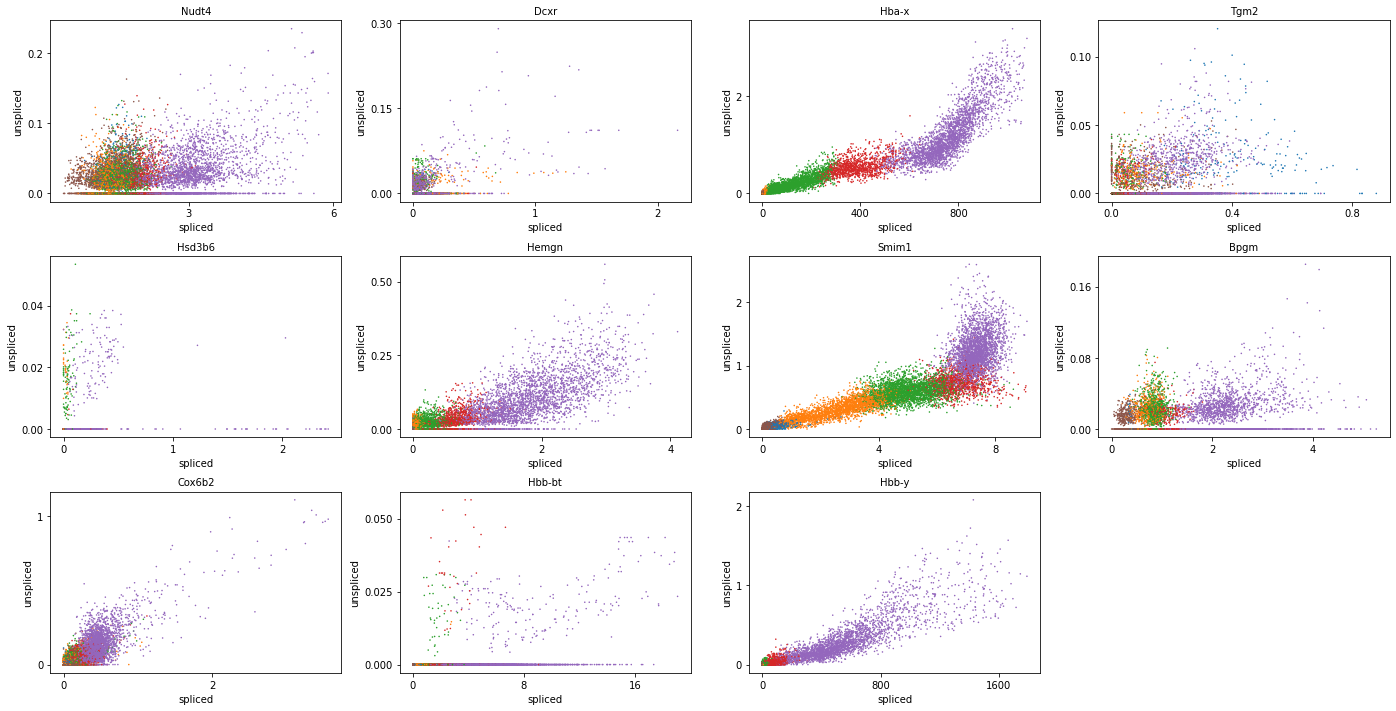

In [55]:
scv.pl.scatter(adata,ncols= 4,basis=lista_def,color='celltype')

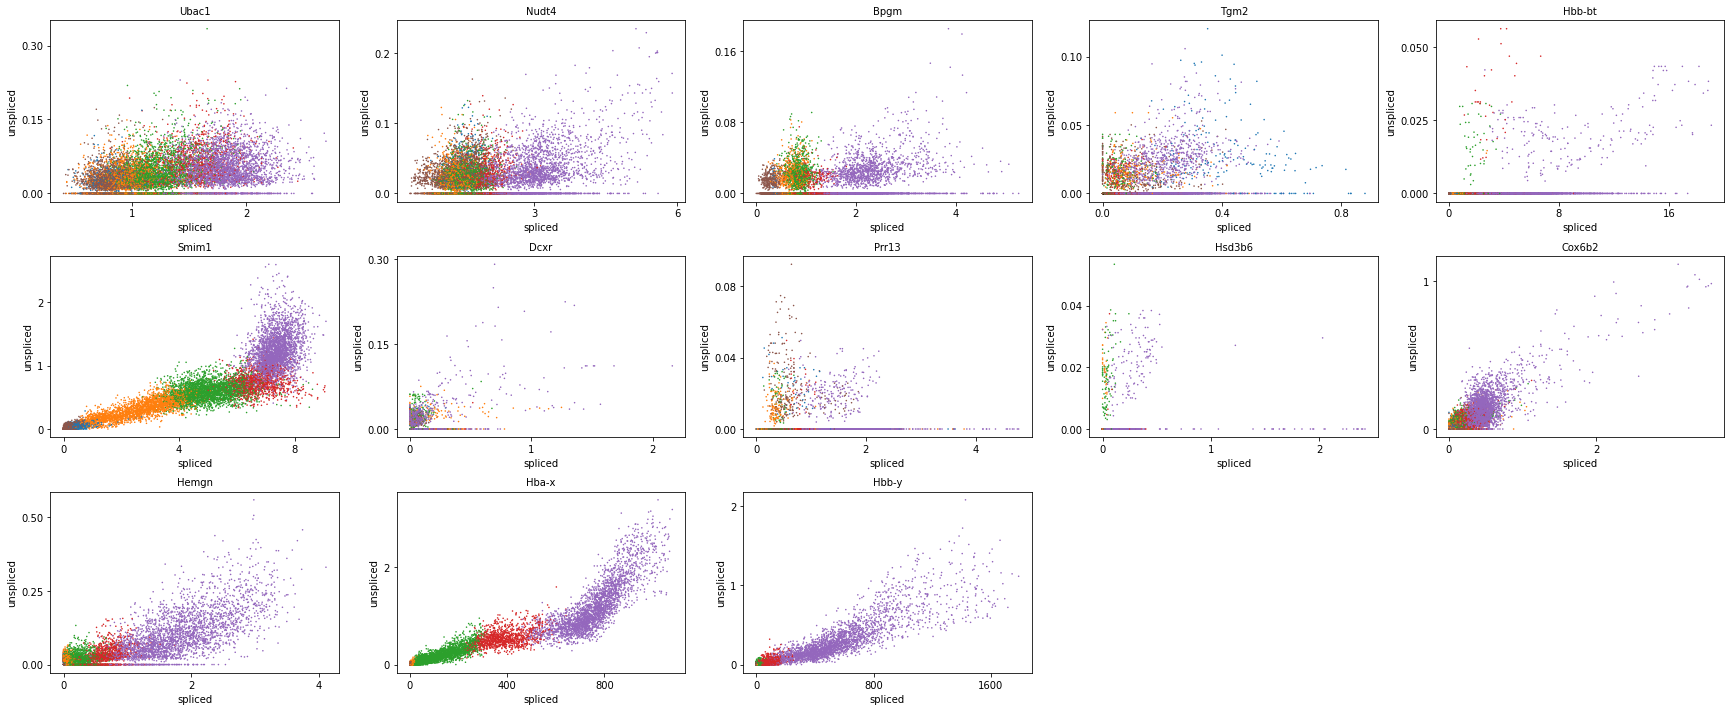

In [56]:
scv.pl.scatter(adata,ncols= 5,basis=rds_ni.index,color='celltype')

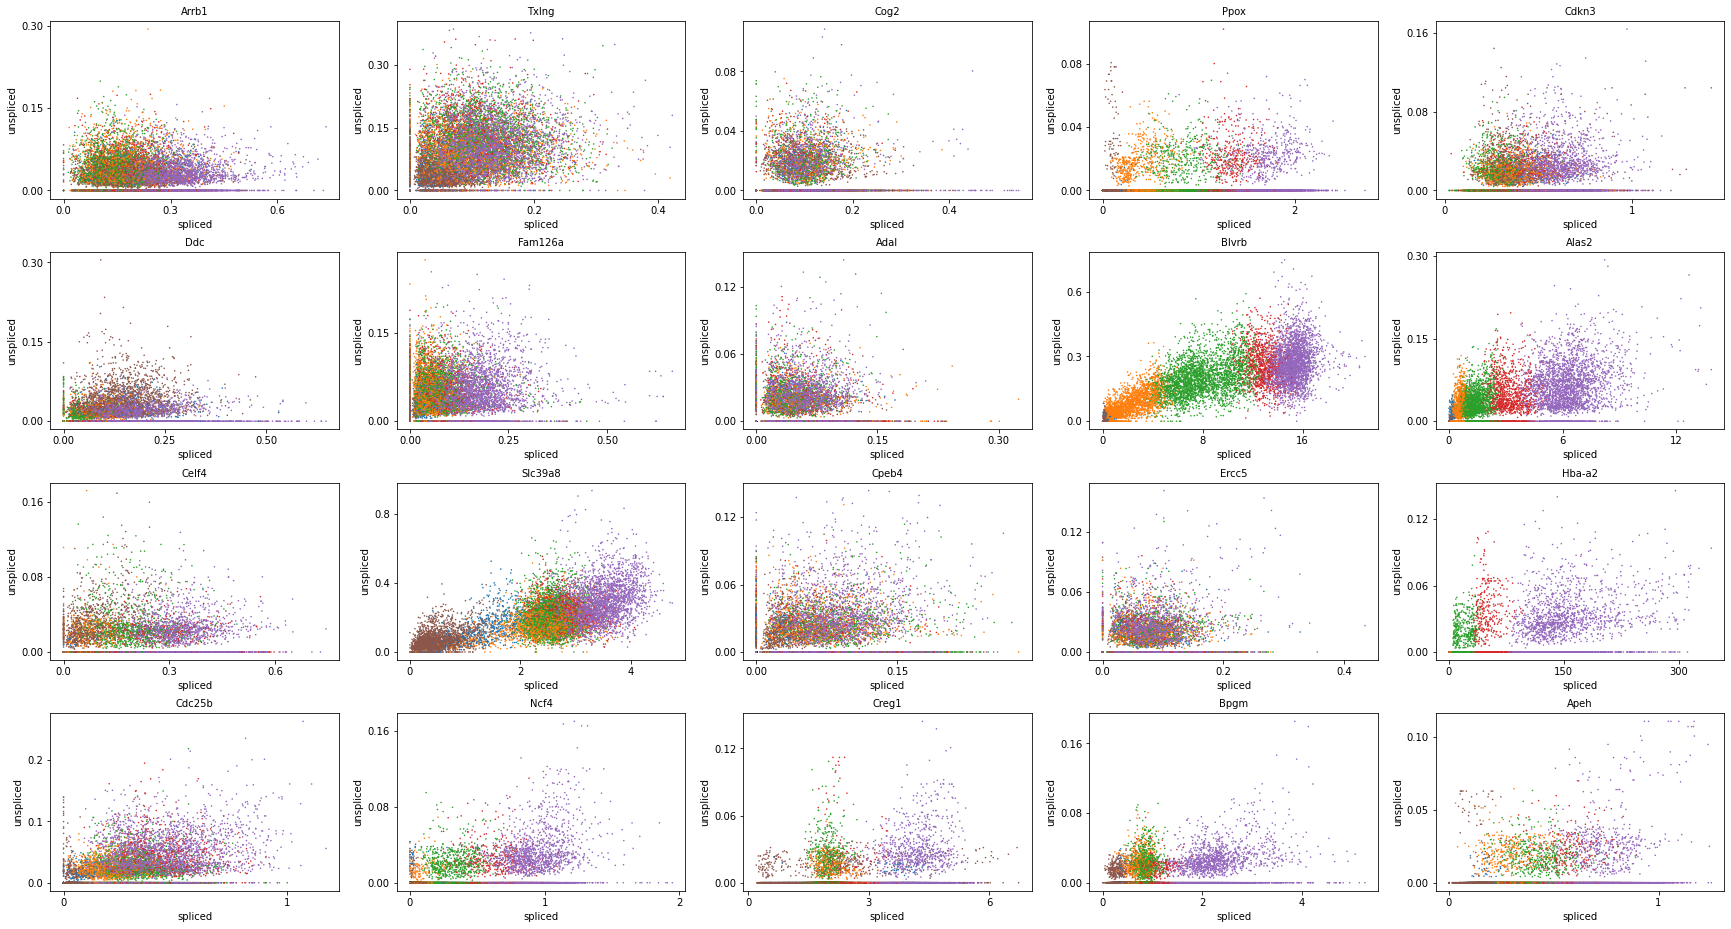

In [57]:
scv.pl.scatter(adata,ncols= 5,basis=rds.index[:20],color='celltype')

In [58]:
lista_bio = ['Hba-x', 'Hba-a1', 'Hba-a2', 'Hbb-bt',  'Hbb-bh1', 'Hbb-y','Hemgn',
             'Smim1','Bpgm','Ppox','Slc4a1','Slc25a37','Nfe2','Grap2',
            'Rhag','Fech','Redrum','Fam210b','Mllt3','Blvrb']

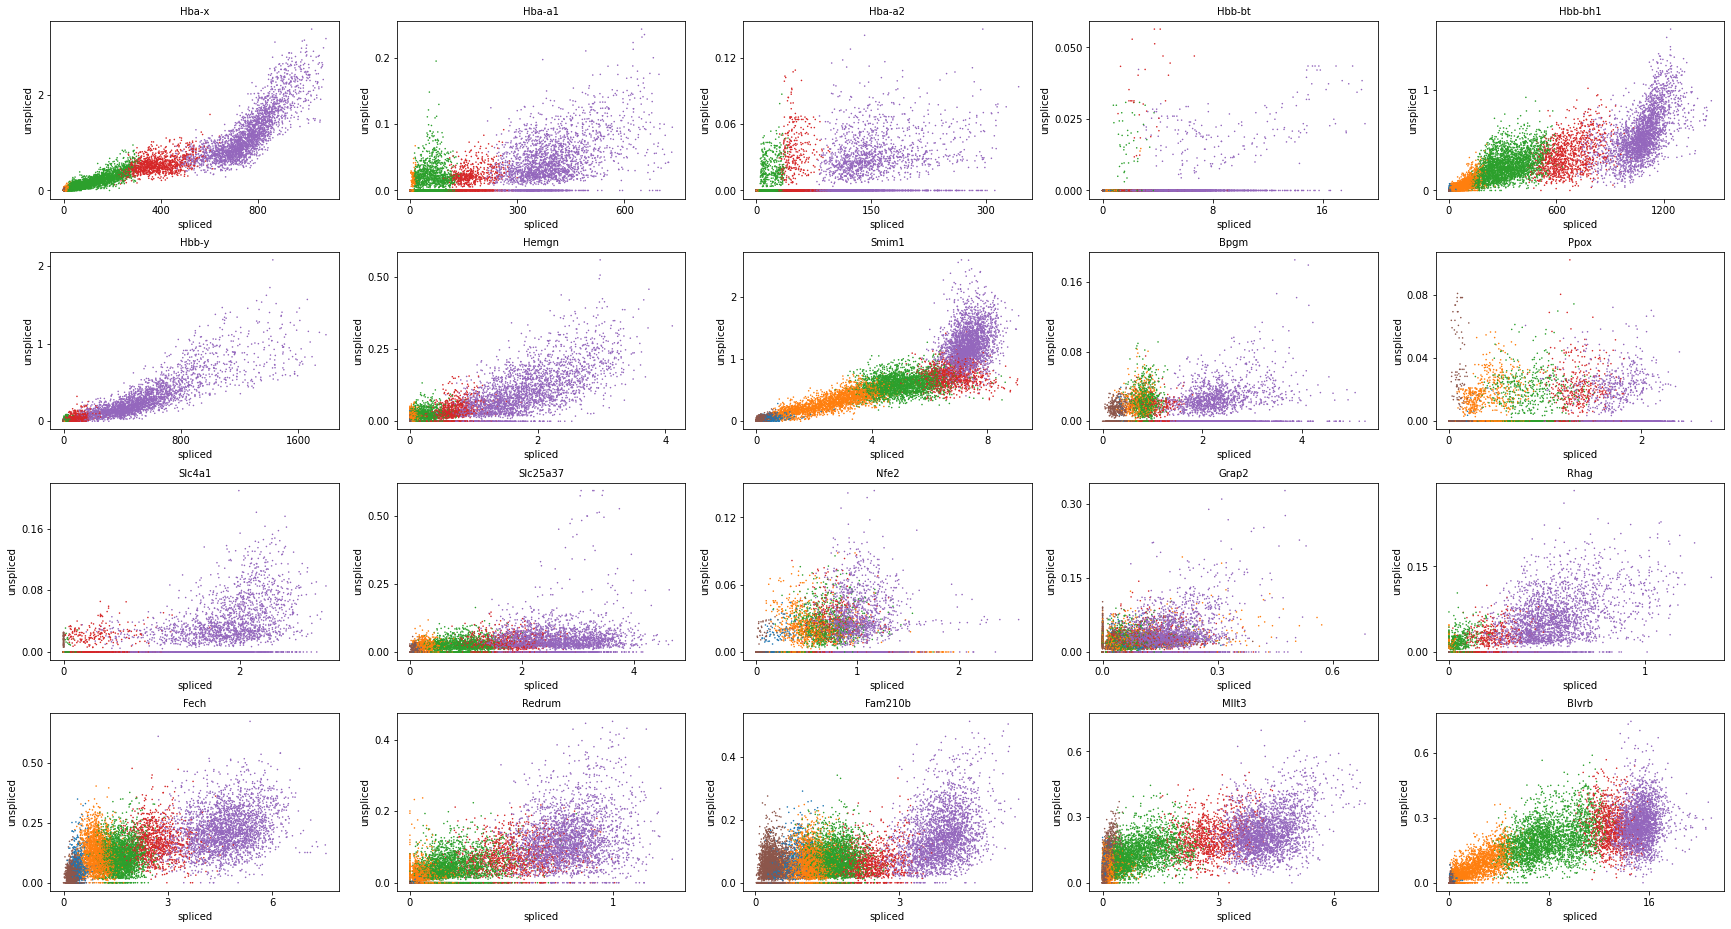

In [59]:
scv.pl.scatter(adata,ncols= 5,basis=lista_bio,color='celltype')

In [60]:
ln3 = ['Abcb6', 'Ppox', 'Ercc5', 'Spta1', 'Slc30a10', 'Reep6', 'Hmmr', 'Ccng1',
       'Hn1', 'Hba-a1', 'Unc45b', 'Narf', 'Ccnb1', 'Tmem14c', 'Azin1', 'Ift27',
       'Grap2', 'Abcc5', 'Dlg1', 'Mrap', 'Cdkn1a', 'Ino80c', 'Fth1', 'Tubb4b',
       'Epb42', 'Fam65c', 'Aurka', 'Csrnp3', 'Cd59a', '5730508B09Rik', 'Car2',
       'Mbnl1', 'Urod', 'Ipo13', 'Smap2', 'Minos1', 'Rhd', 'Atp8a1', 'Slc7a1',
       'Snca', 'St3gal5', 'Tmem86b', 'Cox6b2', 'Nipa1', 'Nrip3', 'Uros',
       'Ano1', 'Kmt5c', 'Aqp8', 'Tspan32', 'Prdx2', 'Zfpm1', 'Olfm2', 'Hmbs',
       'Xist', 'Txlng']

In [61]:
lp=['Mdm4', 'Btg2', 'Prdx6', 'Ercc5', 'Carf', 'Spta1', 'Nudt4', 'Fbxo7',
       'Fignl1', 'Spns2', 'Hba-x', 'G2e3', 'Ero1l', 'Arhgap22', 'Usp25',
       'Celf4', 'Sema6a', 'Taf4b', 'Cox8a', 'Vwce', 'Proser2', '1700037H04Rik',
       'Plk4', 'Larp1b', 'Srsf12', 'Anp32b', 'Eps15', 'Rims3', 'E2f2',
       'Atp8a1', 'Ulk1', 'Slc7a1', 'Mkrn1', 'Bpgm', 'Zfp715', 'Ppfia3', 'Uros',
       'Kmt5c', 'Ucp2', 'Ank1', 'Gypa', 'Cpne7', 'Hmbs', 'Zfp609', 'Herc1',
       'G6pdx', 'Nlgn3']

In [62]:
list(set(lp) & set(ln3))

['Uros', 'Hmbs', 'Kmt5c', 'Ercc5', 'Slc7a1', 'Atp8a1', 'Spta1']

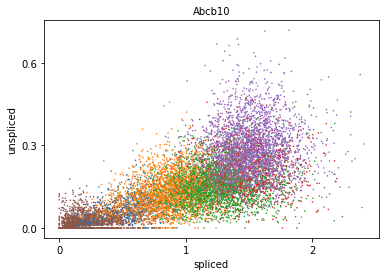

In [63]:
scv.pl.scatter(adata,ncols= 4,basis=gene,color='celltype')

In [ ]:
scv.tl.recover_dynamics(adata)

recovering dynamics
... 1%

In [ ]:
scv.pl.scatter(adata,ncols= 4,basis=lista_def,color='celltype')